In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [33]:
# Load the dataset
df = pd.read_csv("diabetes_prediction_dataset_2000.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [35]:
df.columns.tolist()

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

In [8]:
#target column is diabetes
X = df.drop("diabetes", axis=1)
y = df["diabetes"]
print(X,y)

      gender   age  hypertension  heart_disease smoking_history    bmi  \
0     Female  13.0             0              0         No Info  20.82   
1     Female   3.0             0              0         No Info  21.00   
2       Male  63.0             0              0          former  25.32   
3     Female   2.0             0              0           never  17.43   
4     Female  33.0             0              0     not current  40.08   
...      ...   ...           ...            ...             ...    ...   
1995  Female  24.0             0              0         No Info  23.89   
1996  Female  46.0             0              0         No Info  32.89   
1997    Male  15.0             0              0         current  20.88   
1998  Female  47.0             0              0           never  24.59   
1999    Male  69.0             1              1           never  27.32   

      HbA1c_level  blood_glucose_level  
0             5.8                  126  
1             5.0            

In [54]:
#Separating numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns
print(numeric_features)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level'],
      dtype='object')


In [55]:
#preprocessing pipeline-SimpleImputer(Numerical),Onehotendoder(Categorical)
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])
prep = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features)])

In [38]:
#model creation
nb_model = Pipeline(steps=[("preprocessing", prep),("naive_bayes", GaussianNB())])

In [13]:
#One Hot Encoding used for sparse ouptput
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [39]:
#for preprocessing
prep = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features)])

In [40]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
#trian Model
nb_model.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('naive_bayes', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
#model prediction
nb_pred = nb_model.predict(x_test)
nb_prob = nb_model.predict_proba(x_test)[:, 1]

In [46]:
#evaluation mertics
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test,nb_pred)
nb_recall = recall_score(y_test,nb_pred)
nb_f1 = f1_score(y_test,nb_pred,average="weighted")
nb_auc = roc_auc_score(y_test,nb_prob)

In [47]:
print("Gaussian Naive Bayes Classification Results")

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("Weighted F1:", nb_f1)
print("ROC-AUC  :", nb_auc)

Gaussian Naive Bayes Classification Results
Accuracy : 0.8975
Precision: 0.42857142857142855
Recall   : 0.7272727272727273
Weighted F1: 0.9090865057918108
ROC-AUC  : 0.921476343819668


In [22]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       367
           1       0.48      0.76      0.59        33

    accuracy                           0.91       400
   macro avg       0.73      0.84      0.77       400
weighted avg       0.94      0.91      0.92       400



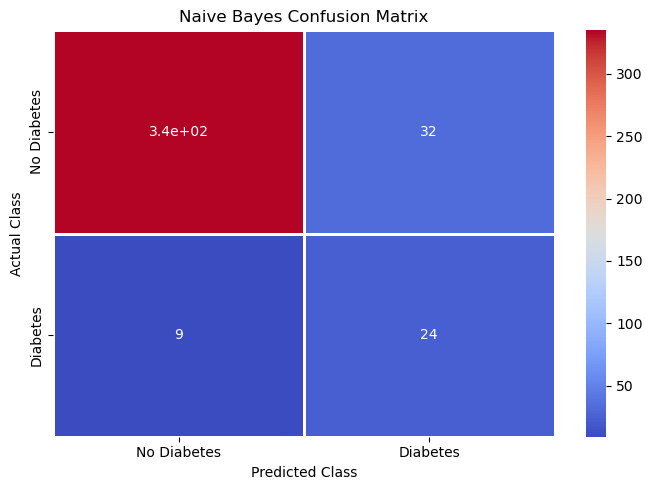

In [56]:
cm_nb = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb,annot=True,cmap="coolwarm",linewidths=2,linecolor="white",xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64
Features shape: (1996, 8)
Target shape: (1996,)
Cate

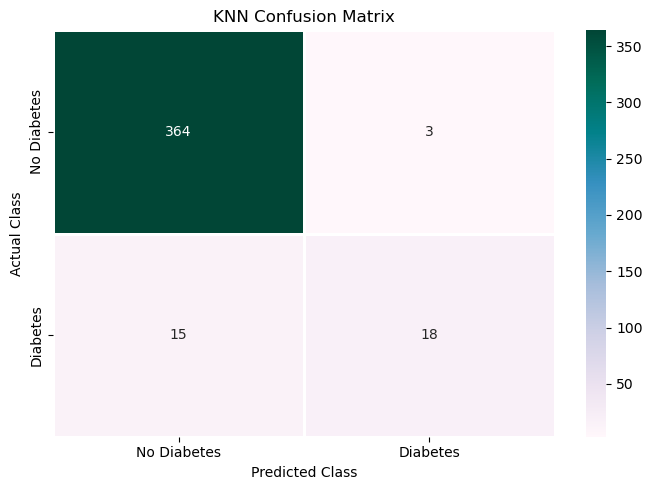

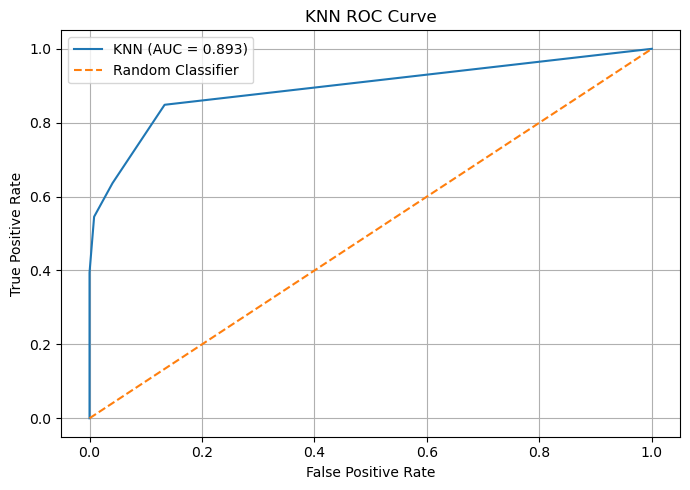

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


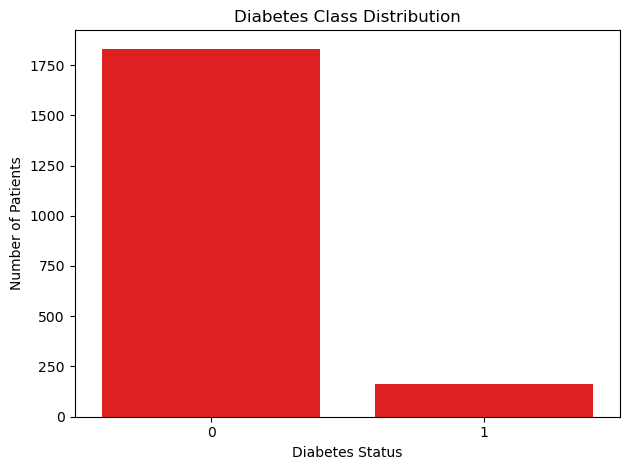

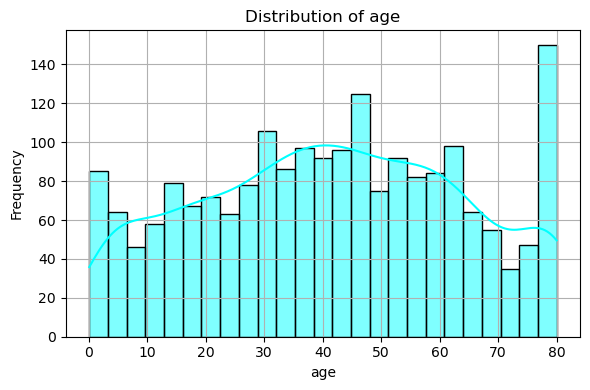

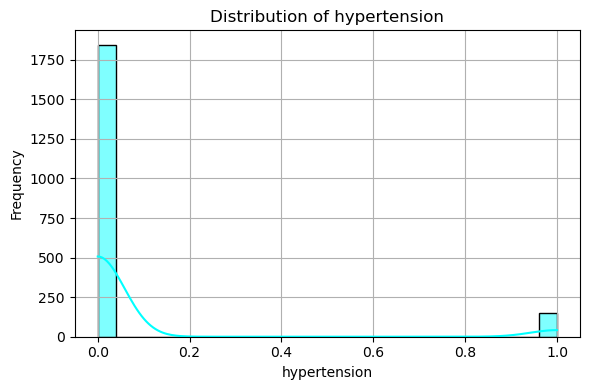

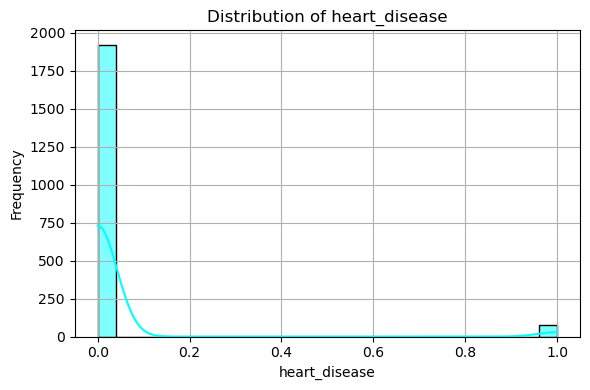

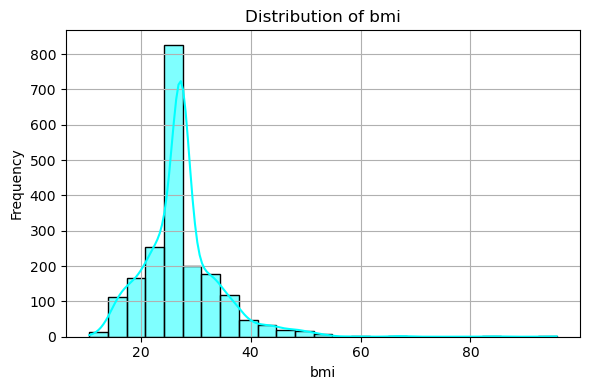

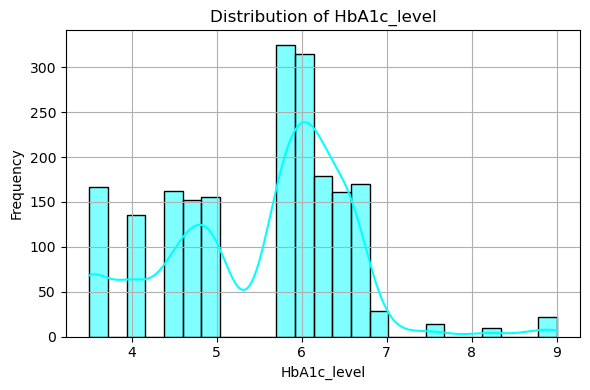

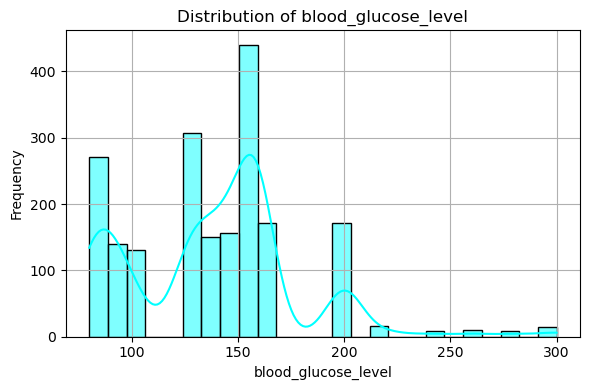

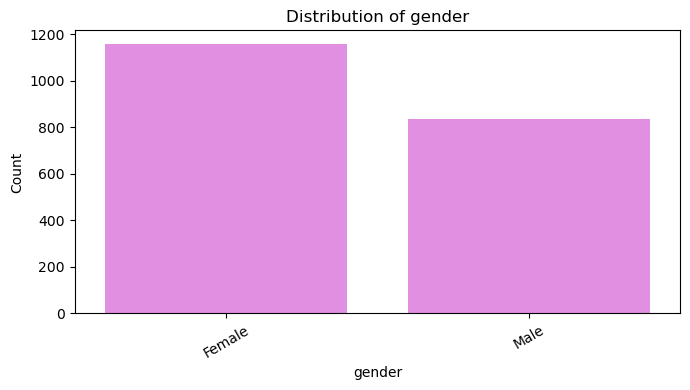

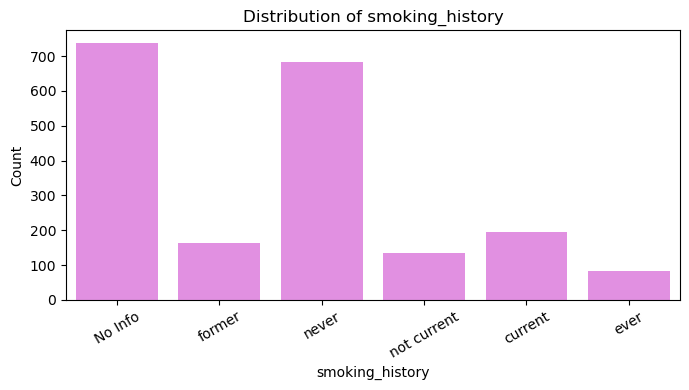

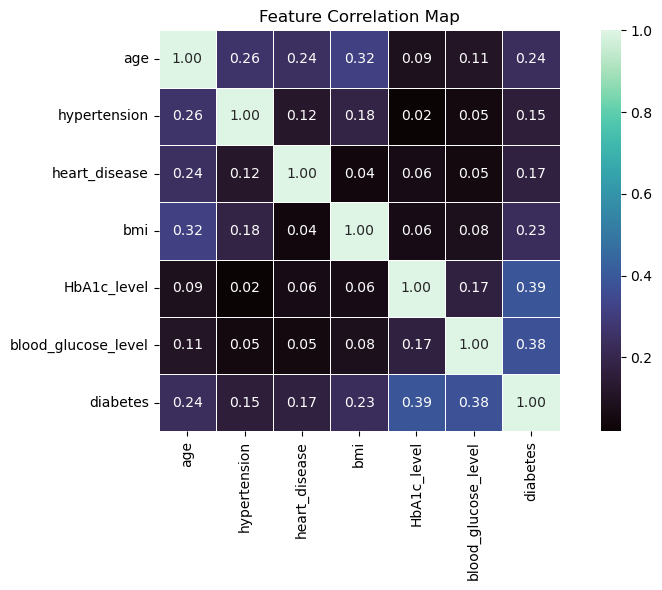

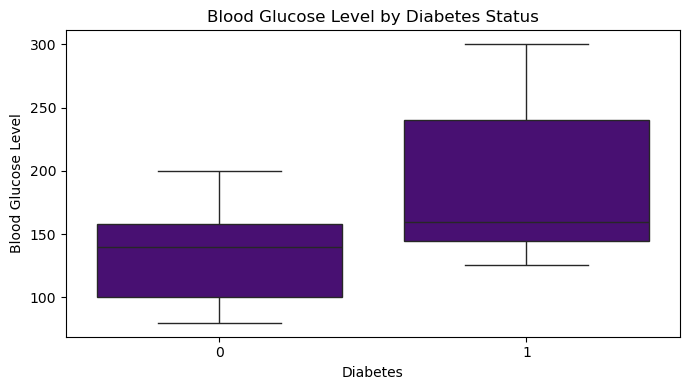

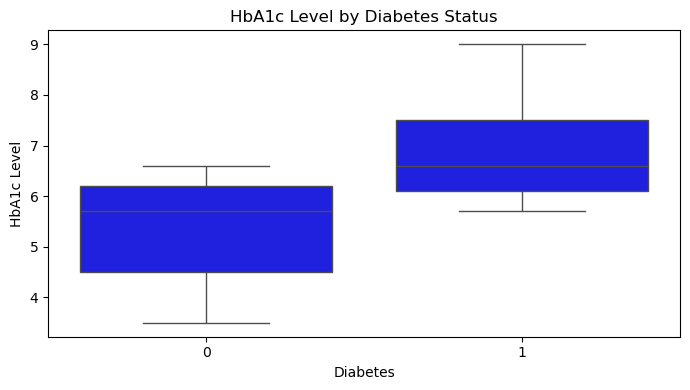

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



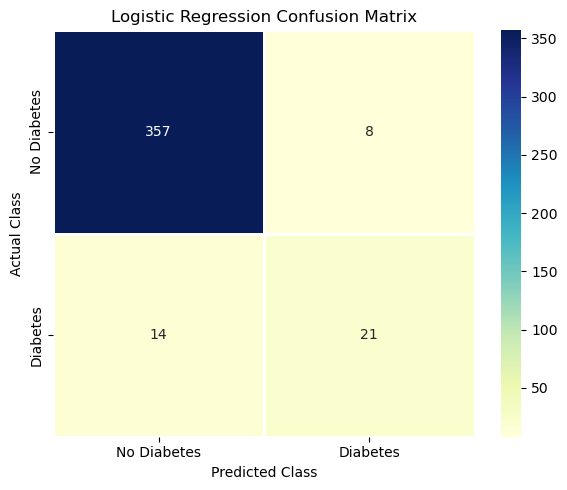

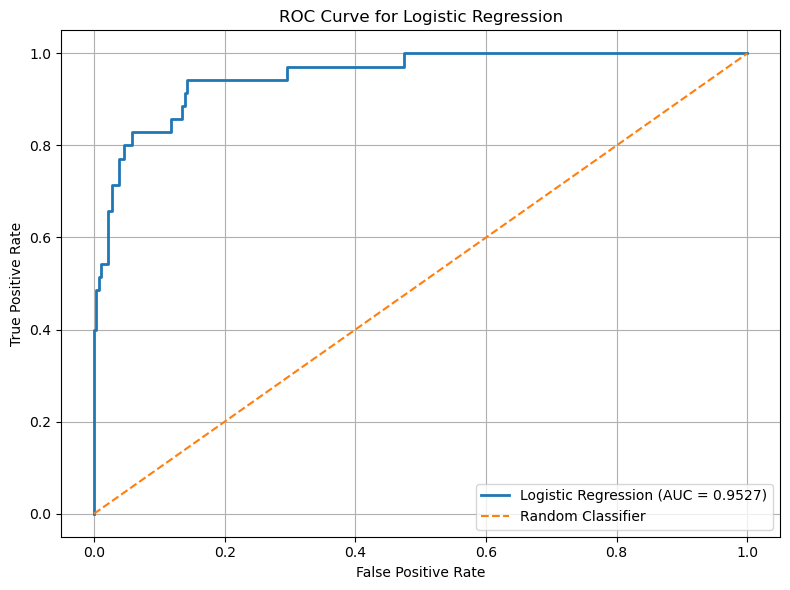

KNN model trained successfully.
First 10 KNN predictions:
[0 0 1 0 0 0 0 0 1 0]
KNN Classification Results
---------------------------
Accuracy    : 0.95
Precision   : 0.8260869565217391
Recall      : 0.5428571428571428
Weighted F1 : 0.9452318988753601
ROC-AUC     : 0.8633268101761251
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       365
           1       0.83      0.54      0.66        35

    accuracy                           0.95       400
   macro avg       0.89      0.77      0.81       400
weighted avg       0.95      0.95      0.95       400



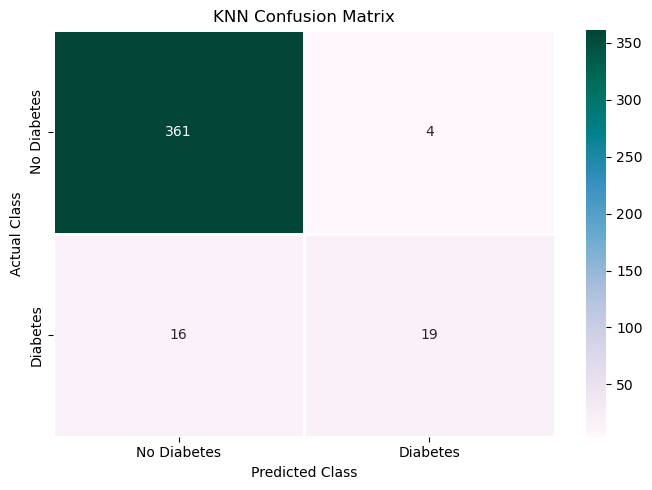

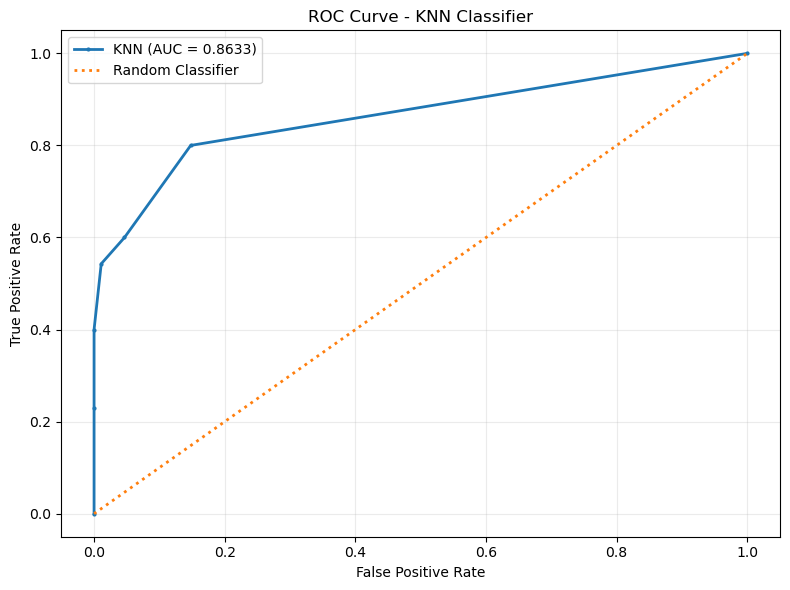

Model comparison


KeyError: "None of ['Metric'] are in the columns"

KeyError: "None of ['Metric'] are in the columns"

In [25]:
%run "classification2_KNN.ipynb"

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4
Shape After Removing duplicates: (1996, 9)
Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


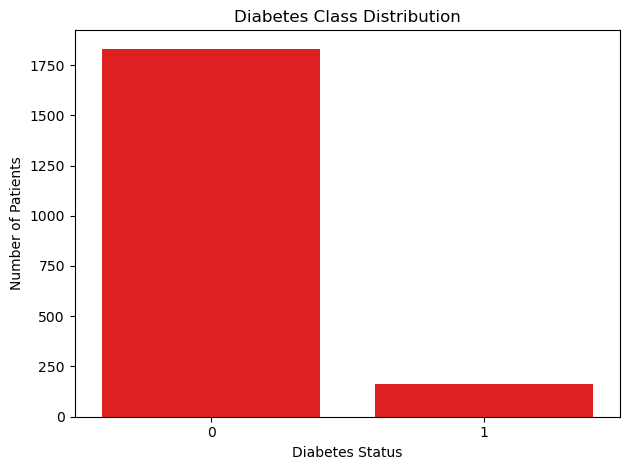

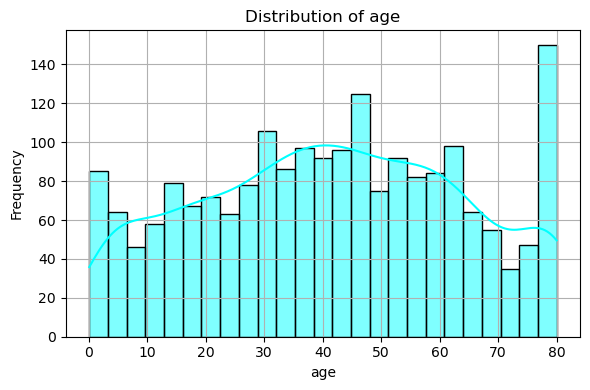

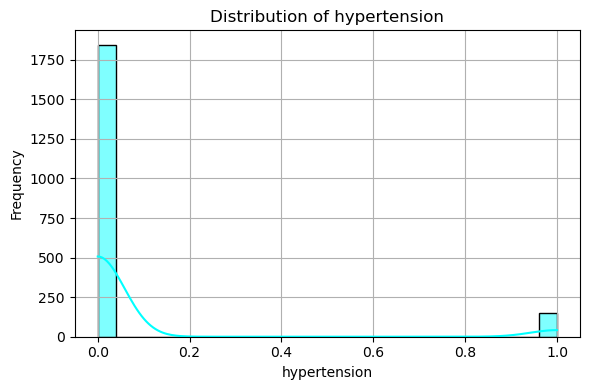

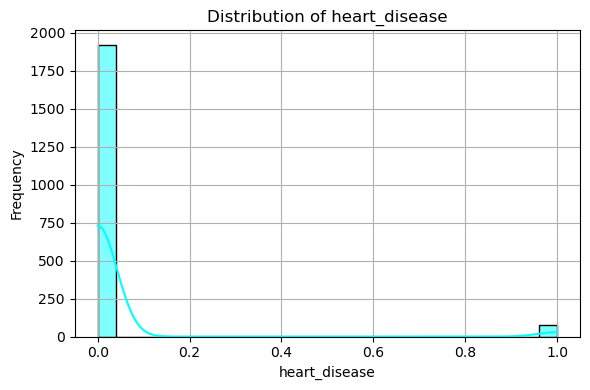

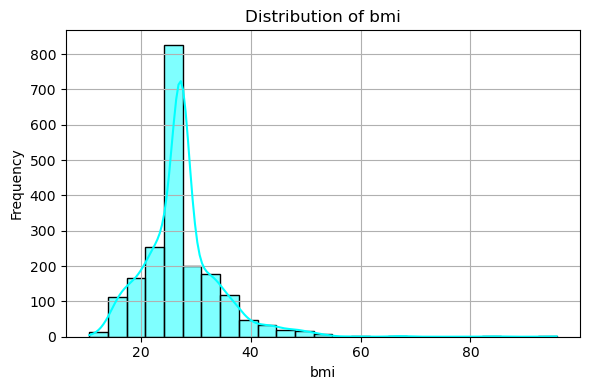

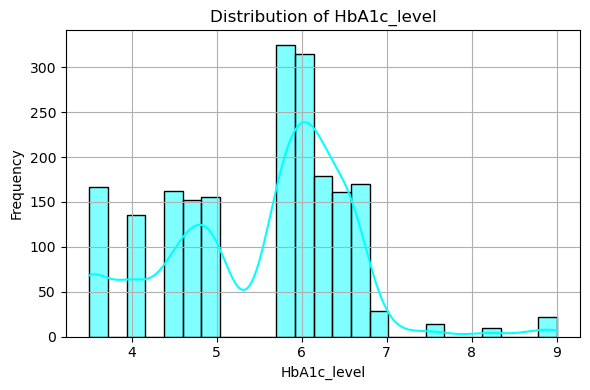

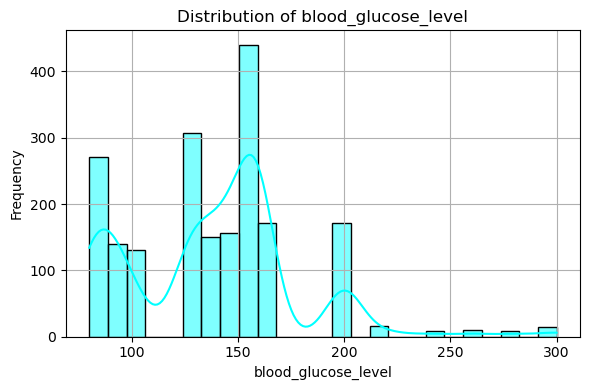

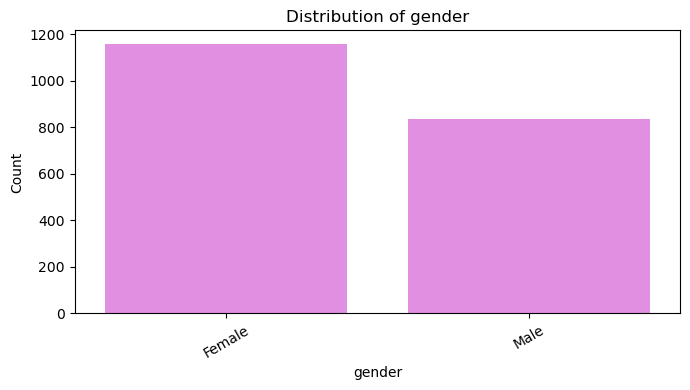

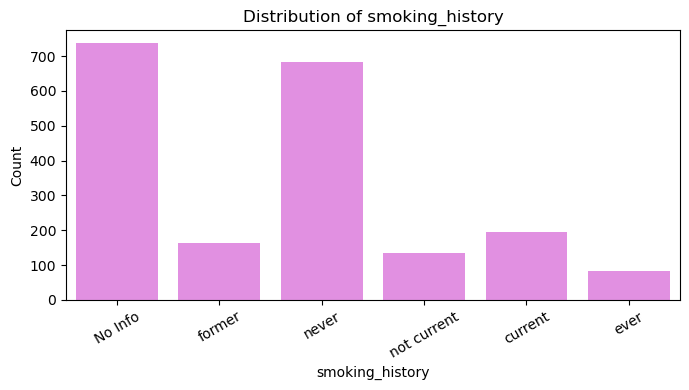

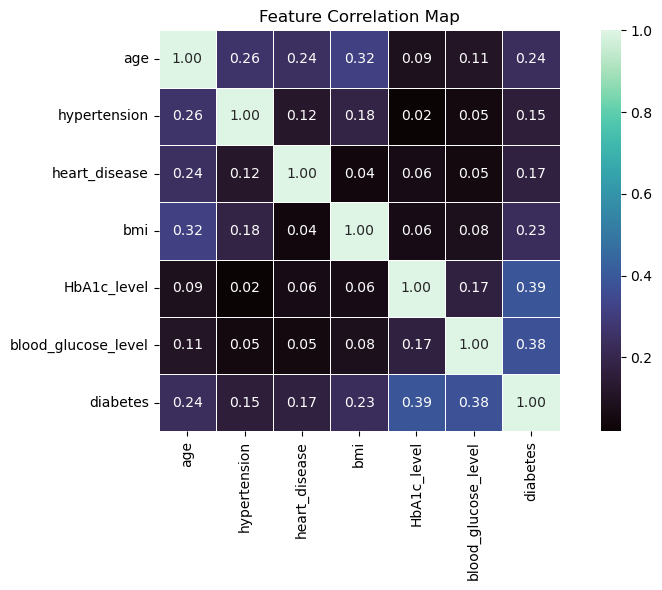

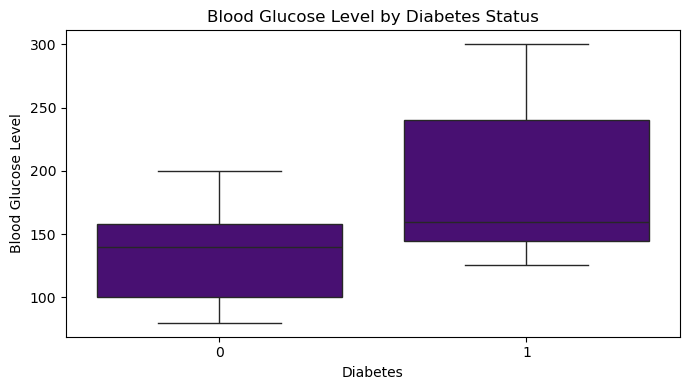

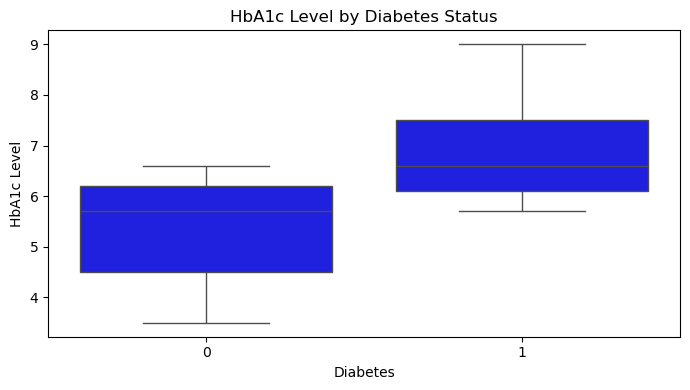

Features shape: (1996, 8)
Target shape: (1996,)
Training data: (1596, 8)
Testing data: (400, 8)
Logistic Regression model trained successfully.
First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]
Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



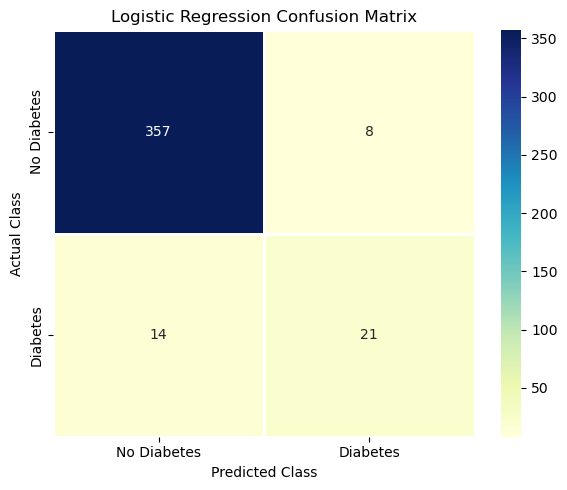

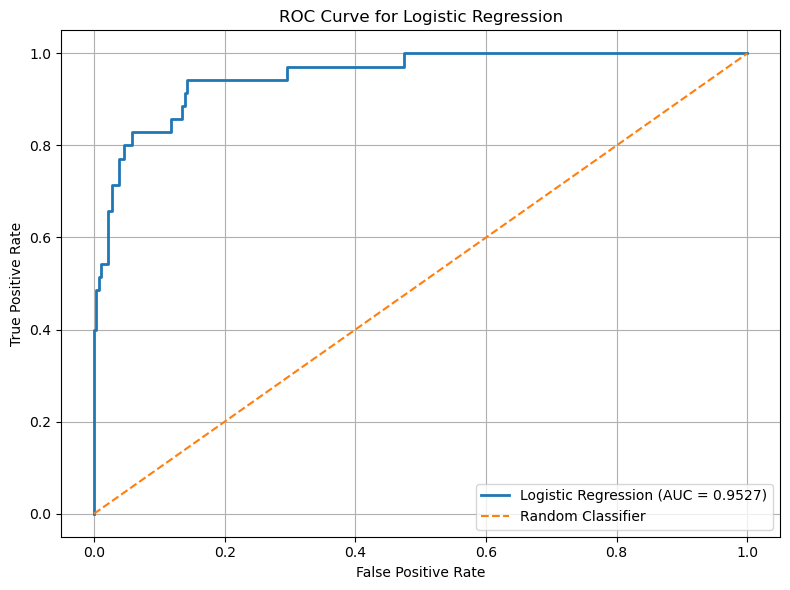

KNN model trained successfully.
First 10 KNN predictions:
[0 0 1 0 0 0 0 0 1 0]
KNN Classification Results
---------------------------
Accuracy    : 0.95
Precision   : 0.8260869565217391
Recall      : 0.5428571428571428
Weighted F1 : 0.9452318988753601
ROC-AUC     : 0.8633268101761251
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       365
           1       0.83      0.54      0.66        35

    accuracy                           0.95       400
   macro avg       0.89      0.77      0.81       400
weighted avg       0.95      0.95      0.95       400



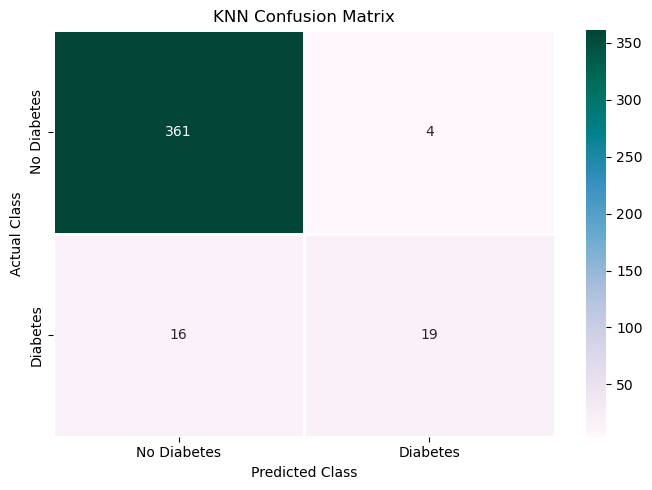

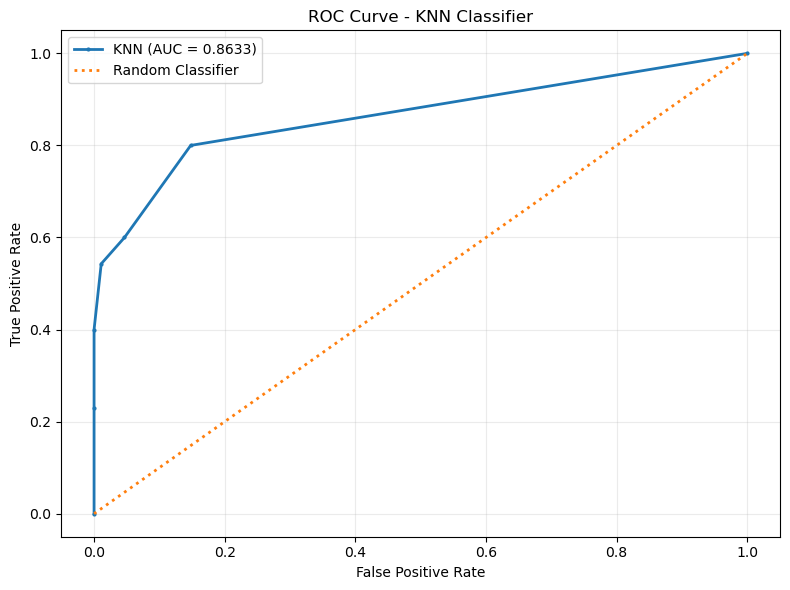

In [26]:
%run "classification1_LR.ipynb"

In [49]:
comparison = pd.DataFrame({
    "Metrics": ["Accuracy","Precision","Recall","Weighted F1","ROC-AUC"],
    "Logistic Regression": [lr_accuracy,lr_precision,lr_recall,lr_f1,lr_auc],
    "KNN": [knn_accuracy,knn_precision,knn_recall,knn_f1,knn_auc],
    "Naive Bayes": [nb_accuracy,nb_precision,nb_recall,nb_f1,nb_auc]
})

comparison

,Metrics,Logistic Regression,KNN,Naive Bayes
0,Accuracy,0.945000,0.950000,0.897500
1,Precision,0.724138,0.826087,0.428571
2,Recall,0.600000,0.542857,0.727273
3,Weighted F1,0.942646,0.945232,0.909087
4,ROC-AUC,0.952720,0.863327,0.921476


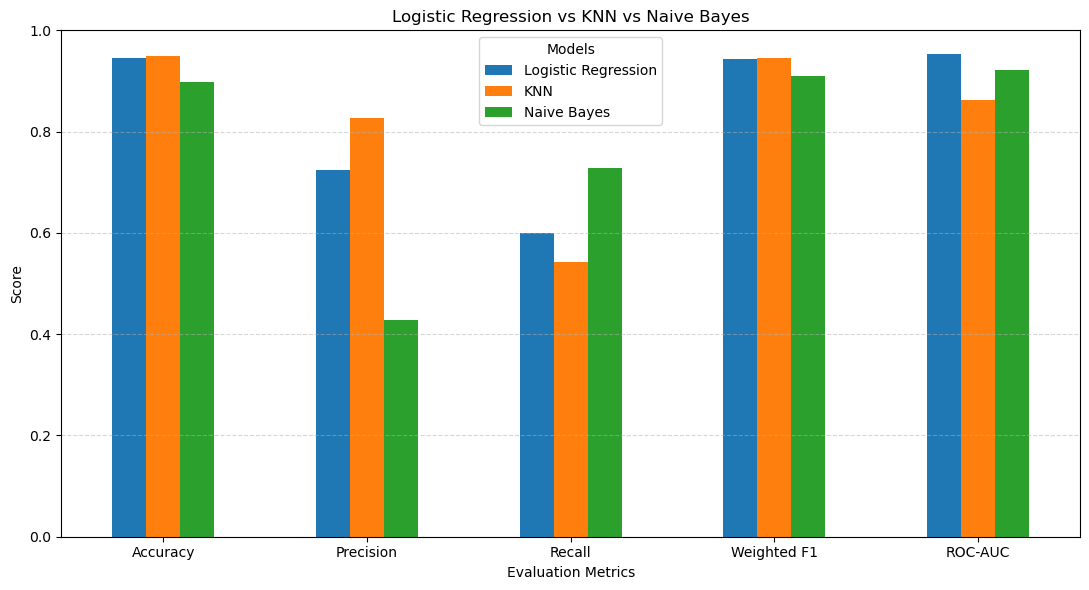

In [50]:
comparison.set_index("Metrics").plot(kind="bar",figsize=(11, 6))
plt.title("Logistic Regression vs KNN vs Naive Bayes")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Models")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
#ROC CURVE
lr_fpr, lr_tpr, _ = roc_curve(y_test,lr_prob)
knn_fpr, knn_tpr, _ = roc_curve(y_test,knn_prob)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)

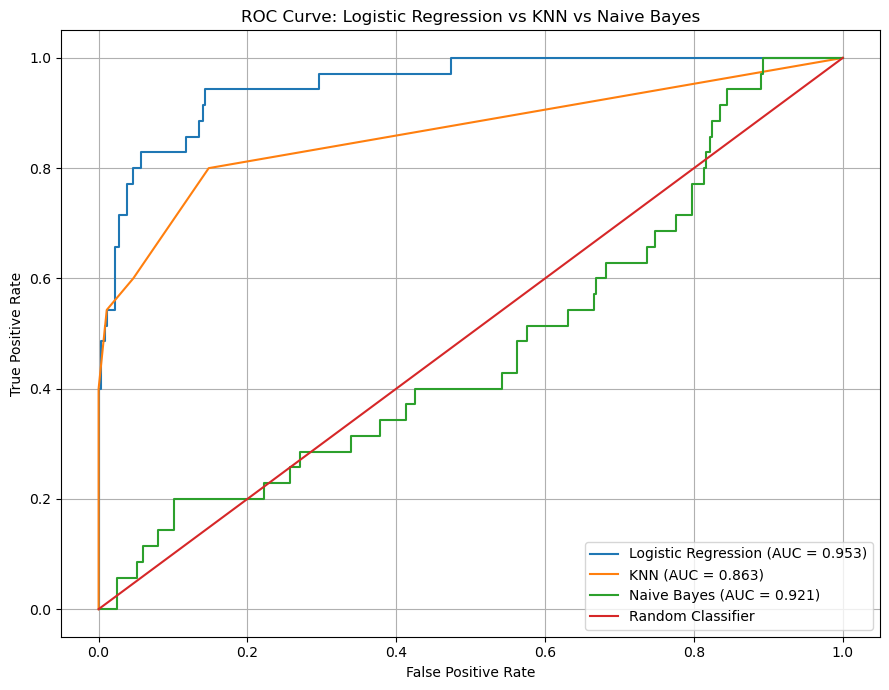

In [61]:
plt.figure(figsize=(9, 7))
plt.plot(lr_fpr,lr_tpr,label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(knn_fpr,knn_tpr,label=f"KNN (AUC = {knn_auc:.3f})")
plt.plot(nb_fpr,nb_tpr,label=f"Naive Bayes (AUC = {nb_auc:.3f})")
plt.plot([0, 1],[0, 1],linestyle="-",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression vs KNN vs Naive Bayes")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()